In [69]:
from auxillary.graph import *
from auxillary.helper import *
import matplotlib.pyplot as plt
from collections import Counter
import random

In [ ]:
# helper function just like MVC, to check if we have an IS
def is_independent_set(G, S):
    for node in S:
        for neighbor in G.adj[node]:
            if neighbor in S:
                return False
    return True

# MIS finds the Maximum Independent Set of a graph G 
# we have roughly the same ida as MVC< just working backwards
# we check all subsets, if they are indepent sets and larger than our best update it
def MIS(G):
    nodes = [i for i in range(G.number_of_nodes())]
    subsets = power_set(nodes)
    max_cover = []
    for subset in subsets:
        if len(subset) <= len(max_cover): 
            continue
        if is_independent_set(G, subset):
            if len(subset) > len(max_cover):
                max_cover = subset
    return max_cover

In [82]:
def test_and_plot_MIS_MVC(num_nodes, num_edges, trials):
    mis_sizes = []
    mvc_sizes = []
    perfect_matches = 0
    for _ in range(trials):
        G = create_random_graph(num_nodes, num_edges)
        mis = sorted(MIS(G))
        mvc = sorted(MVC(G))
        mis_sizes.append(len(mis))
        mvc_sizes.append(len(mvc))
        c_mis = sorted([i for i in range(G.number_of_nodes()) if i not in mis])
        c_mvc = sorted([i for i in range(G.number_of_nodes()) if i not in mvc])

        if len(mis) == len(c_mvc) and len(mvc) == len(c_mis):
            perfect_matches += 1

    pair_counts = Counter(zip(mis_sizes, mvc_sizes))
        
    x_vals = [pair[0] for pair in pair_counts.keys()]
    y_vals = [pair[1] for pair in pair_counts.keys()]

    # Scale the dot sizes based on how frequently that outcome happened
    dot_sizes = [count * 10 for count in pair_counts.values()] 

    plt.figure(figsize=(8, 6))
    plt.scatter(x_vals, y_vals, s=dot_sizes, alpha=0.7, c='blue', edgecolors='black')

    # Draw  x + y = n
    plt.plot([0, num_nodes], [num_nodes, 0], color='red', linestyle='--', label=f'Theorem Line (x + y = {num_nodes})')

    # Formatting the graph
    plt.title(f'MIS Size vs MVC Size over {trials} Trials\n({num_nodes}-Node Graphs, {num_edges} Edges)')
    plt.xlabel('Size of Maximum Independent Set')
    plt.ylabel('Size of Minimum Vertex Cover')
    plt.xticks(range(num_nodes + 1))
    plt.yticks(range(num_nodes + 1))
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    plt.show()   
    

Notes: First, we tested and noticed the size of MIS + MVC = size of graph. They were not identical complements, since there are many possible MIS and MVC, but the complement is ALWAYS te opposoite

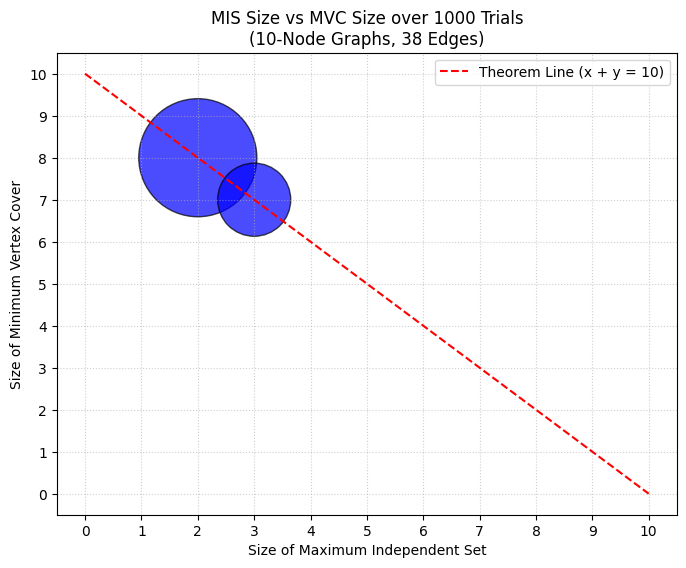

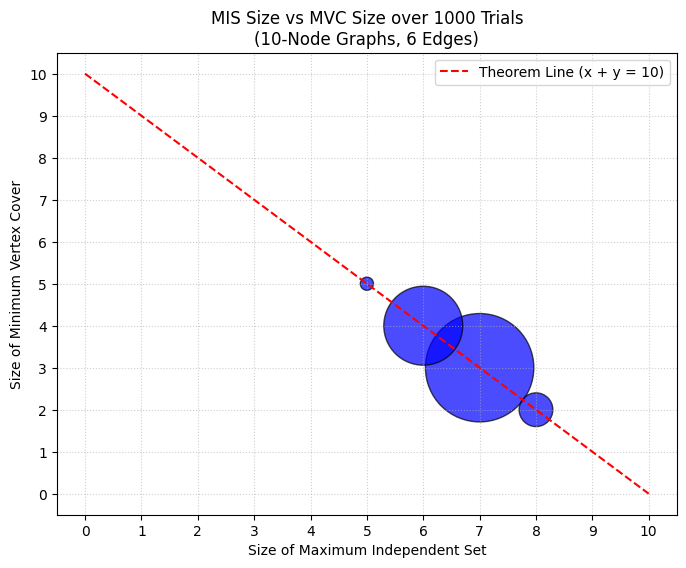

In [83]:
nodes = 10
max_edges = nodes * (nodes - 1) // 2

test_and_plot_MIS_MVC(nodes, int(max_edges * 0.85), 1000)
test_and_plot_MIS_MVC(nodes, int(max_edges * 0.15), 1000)